In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the data
df = pd.read_csv('cyberbullying_tweets.csv')
print('Original shape:', df.shape)
df.head()

Original shape: (47692, 2)


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [3]:
# Delete duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f'Removed {before - df.shape[0]} duplicate rows. Now: {df.shape[0]} rows')

Removed 36 duplicate rows. Now: 47656 rows


In [4]:
# Keep only 'age' and 'not_cyberbullying' labels
df = df[df['cyberbullying_type'].isin(['age', 'not_cyberbullying'])].copy()
print('After filtering to two classes:', df.shape)
df['cyberbullying_type'].value_counts()

After filtering to two classes: (15929, 2)


cyberbullying_type
age                  7992
not_cyberbullying    7937
Name: count, dtype: int64

In [5]:
# Change labels to binary: age -> 1, not_cyberbullying -> 0
df['label'] = df['cyberbullying_type'].map({'age': 1, 'not_cyberbullying': 0})
df[['tweet_text', 'cyberbullying_type', 'label']].head()

,tweet_text,cyberbullying_type,label
0,"In other words #katandandre, your food was cra...",not_cyberbullying,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0


In [6]:
# Save a copy CSV with only these two labels (now binary)
df.to_csv('cyberbullying_age_vs_not.csv', index=False)
print('Saved: cyberbullying_age_vs_not.csv')

Saved: cyberbullying_age_vs_not.csv


In [7]:
# Show the count of each class
counts = df['label'].value_counts().sort_index()
print('0 = not_cyberbullying, 1 = age')
print(counts)

0 = not_cyberbullying, 1 = age
label
0    7937
1    7992
Name: count, dtype: int64


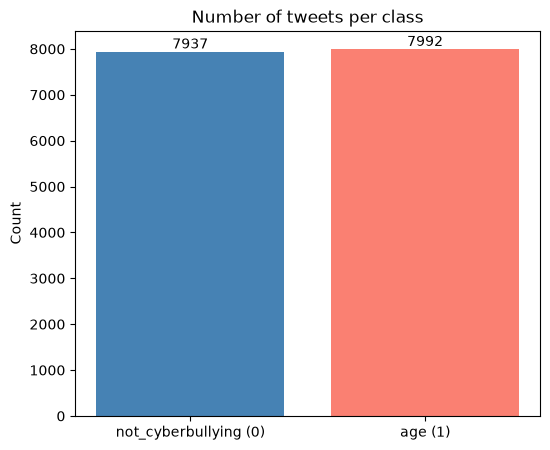

In [8]:
# Show the count graphically
plt.figure(figsize=(6, 5))
plt.bar(['not_cyberbullying (0)', 'age (1)'], counts.values, color=['steelblue', 'salmon'])
plt.title('Number of tweets per class')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()